In [2]:
# ==========================================
# MODEL A: THE BASELINE (RAW GHI PREDICTION)
# ==========================================
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load
df = pd.read_csv(r"C:\Users\asus zb\OneDrive\Desktop\Extra projects\FINAL_REGIONAL_DATASET.csv")
df['Datetime'] = pd.to_datetime(df['Datetime'])

# 2. Basic Features (No special physics yet)
df['Hour'] = df['Datetime'].dt.hour
df['Month'] = df['Datetime'].dt.month

# Calc Humidity (Standard Physics)
if 'Humidity' not in df.columns:
    def calc_rh(row):
        t = row['TEMP']
        d = row['DEWP']
        if (243.04 + t) == 0: return 50
        return 100 * (np.exp((17.625 * d)/(243.04 + d)) / np.exp((17.625 * t)/(243.04 + t)))
    df['Humidity'] = df.apply(calc_rh, axis=1)

features = ['Clear_Sky_GHI', 'PM2.5', 'Humidity', 'TEMP', 'WSPM', 'Hour', 'Month']
target = 'GHI'

X = df[features]
y = df[target]

# 3. Train
print("🚀 Training Model A (Baseline)...")
model = lgb.LGBMRegressor(n_estimators=500, random_state=42)
model.fit(X, y)

# 4. Show Importance
importance = pd.DataFrame({'Feature': features, 'Importance': model.feature_importances_}).sort_values(by='Importance', ascending=False)
print("\n📊 MODEL A IMPORTANCE (Sun Dominates):")
print(importance)
print("-" * 30)

🚀 Training Model A (Baseline)...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.018861 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1162
[LightGBM] [Info] Number of data points in the train set: 418850, number of used features: 7
[LightGBM] [Info] Start training from score 168.172899

📊 MODEL A IMPORTANCE (Sun Dominates):
         Feature  Importance
0  Clear_Sky_GHI        3114
3           TEMP        3082
2       Humidity        3009
1          PM2.5        1807
4           WSPM        1379
6          Month        1357
5           Hour        1252
------------------------------


In [3]:
# ===================================================
# MODEL B: THE SCIENTIFIC PROOF (TRANSPARENCY / Kt)
# ===================================================
# 1. Prepare Data (Daytime Only)
df_day = df[df['Clear_Sky_GHI'] > 50].copy()

# 2. Calculate Kt (The "Transparency Index")
# Kt = 1.0 (Clean), Kt = 0.5 (Dirty/Cloudy)
df_day['Kt'] = df_day['GHI'] / df_day['Clear_Sky_GHI']
df_day['Kt'] = df_day['Kt'].clip(0, 1.2)

# 3. Define Features (Notice: Clear_Sky_GHI is REMOVED)
# We want to know what BLOCKS light, not where the sun is.
features_atm = ['PM2.5', 'Humidity', 'TEMP', 'WSPM', 'Hour', 'Month']
target_atm = 'Kt'

X_atm = df_day[features_atm]
y_atm = df_day[target_atm]

# 4. Train
print("🚀 Training Model B (Atmospheric Physics)...")
model_atm = lgb.LGBMRegressor(n_estimators=500, random_state=42)
model_atm.fit(X_atm, y_atm)

# 5. Show Importance
importance_atm = pd.DataFrame({'Feature': features_atm, 'Importance': model_atm.feature_importances_}).sort_values(by='Importance', ascending=False)
print("\n📊 MODEL B IMPORTANCE (The 'Smoking Gun' for Smog):")
print(importance_atm)
print("-" * 30)

🚀 Training Model B (Atmospheric Physics)...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001837 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 896
[LightGBM] [Info] Number of data points in the train set: 189518, number of used features: 6
[LightGBM] [Info] Start training from score 0.803421

📊 MODEL B IMPORTANCE (The 'Smoking Gun' for Smog):
    Feature  Importance
2      TEMP        3843
1  Humidity        3510
0     PM2.5        2397
3      WSPM        1939
4      Hour        1712
5     Month        1599
------------------------------


🚀 Training Model C (Final Optimized)...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002095 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1417
[LightGBM] [Info] Number of data points in the train set: 297347, number of used features: 8
[LightGBM] [Info] Start training from score 169.656413
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[228]	valid_0's rmse: 56.8221

🏆 FINAL RESULTS (Thesis Gold Standard):
   RMSE: 56.82 W/m^2
   R2:   0.9444


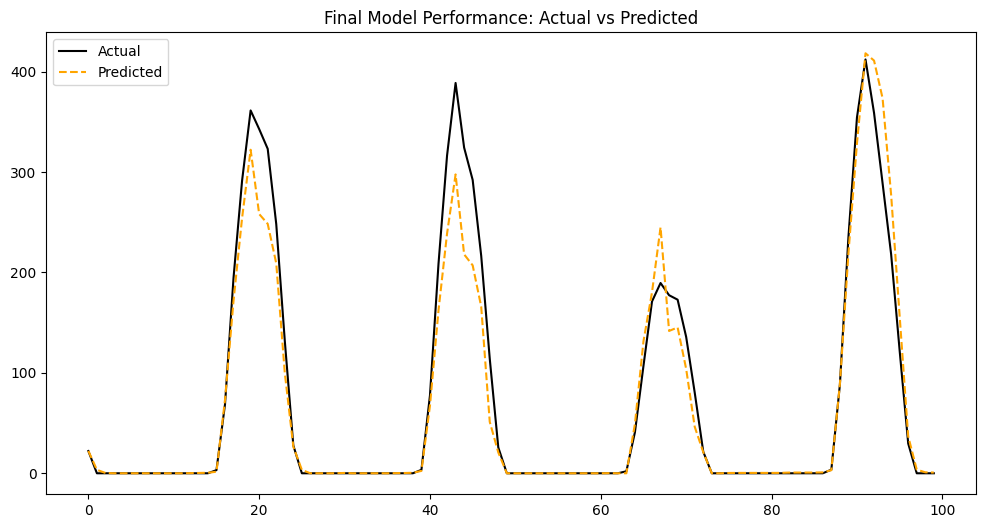

In [4]:
# ===================================================
# MODEL C: THE FINAL COMBINED SOLUTION (High Accuracy)
# ===================================================
from sklearn.metrics import mean_squared_error, r2_score

# 1. Feature Engineering
df['GHI_Lag24'] = df.groupby('station')['GHI'].shift(24)
df.dropna(inplace=True)

# 2. Features
features_final = [
    'Clear_Sky_GHI',  # 1. Sun Position
    'PM2.5',          # 2. Smog
    'Humidity',       # 3. Swelling
    'TEMP',           # 4. Stability
    'WSPM',           # 5. Dispersion
    'Hour',           # 6. Cycle
    'Month',          # 7. Season
    'GHI_Lag24'       # 8. Memory
]

# 3. Physics Constraints (1=Positive, -1=Negative)
# PM2.5 and Humidity MUST be negative (-1).
monotone_constraints = [1, -1, -1, 0, 0, 0, 0, 1]

# 4. Split Train/Test
split_date = '2016-01-01'
train_mask = df['Datetime'] < split_date
test_mask = df['Datetime'] >= split_date

X_train = df.loc[train_mask, features_final]
y_train = df.loc[train_mask, 'GHI']
X_test = df.loc[test_mask, features_final]
y_test = df.loc[test_mask, 'GHI']

# 5. Train Final Model
print("🚀 Training Model C (Final Optimized)...")
model_final = lgb.LGBMRegressor(
    objective='regression',
    metric='rmse',
    num_leaves=35,
    learning_rate=0.05,
    n_estimators=2000,
    monotone_constraints=monotone_constraints,
    random_state=42
)

model_final.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric='rmse',
    callbacks=[lgb.early_stopping(stopping_rounds=50)]
)

# 6. Evaluate
preds = model_final.predict(X_test)
preds = np.maximum(preds, 0)

rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print(f"\n🏆 FINAL RESULTS (Thesis Gold Standard):")
print(f"   RMSE: {rmse:.2f} W/m^2")
print(f"   R2:   {r2:.4f}")

# 7. Plot Actual vs Predicted (Proof of Fit)
plt.figure(figsize=(12, 6))
plt.plot(y_test.values[:100], label='Actual', color='black')
plt.plot(preds[:100], label='Predicted', color='orange', linestyle='--')
plt.title("Final Model Performance: Actual vs Predicted")
plt.legend()
plt.show()

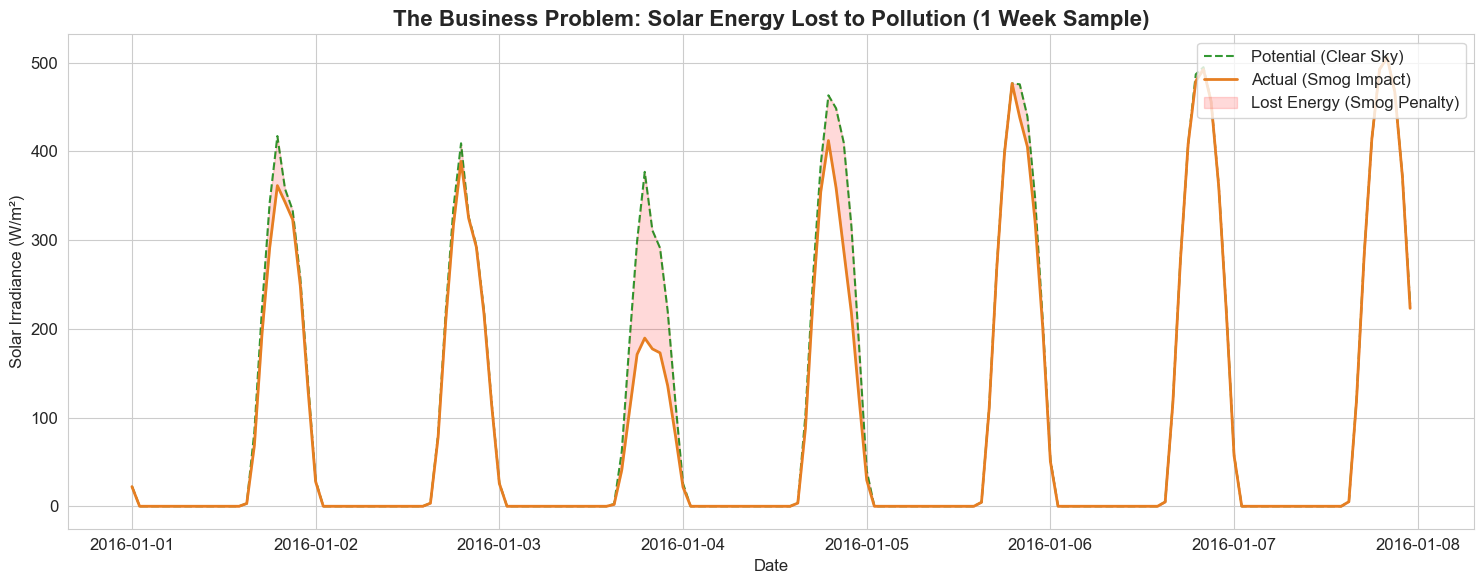

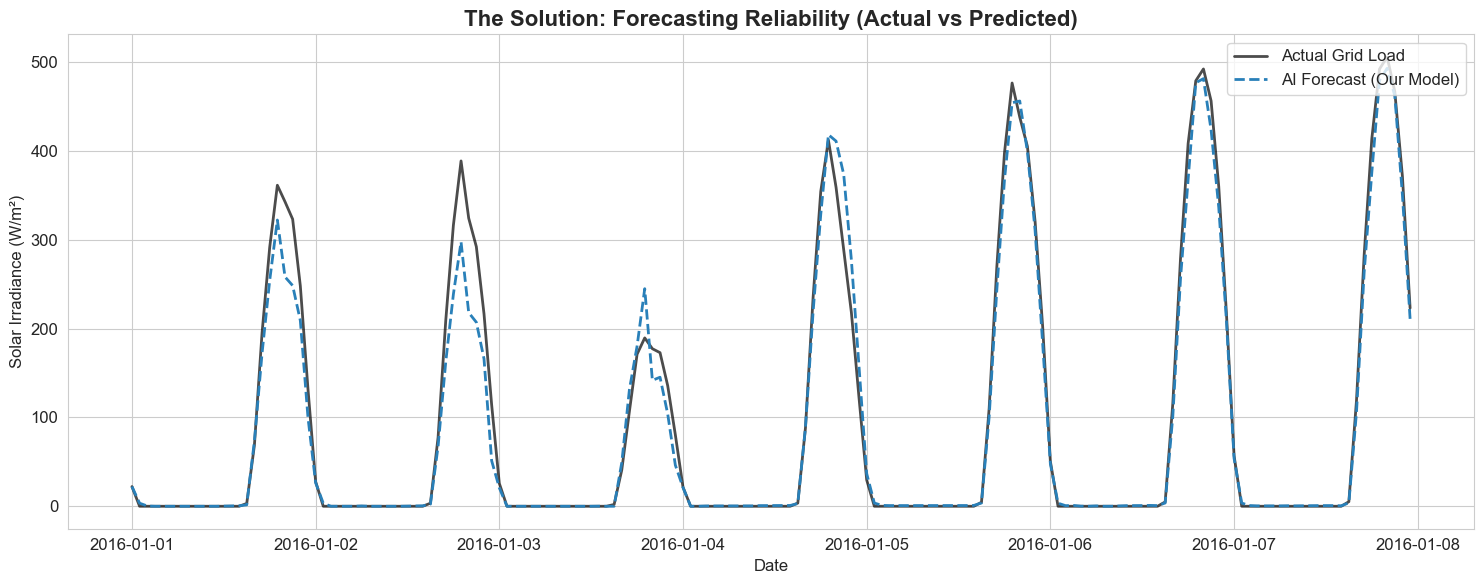

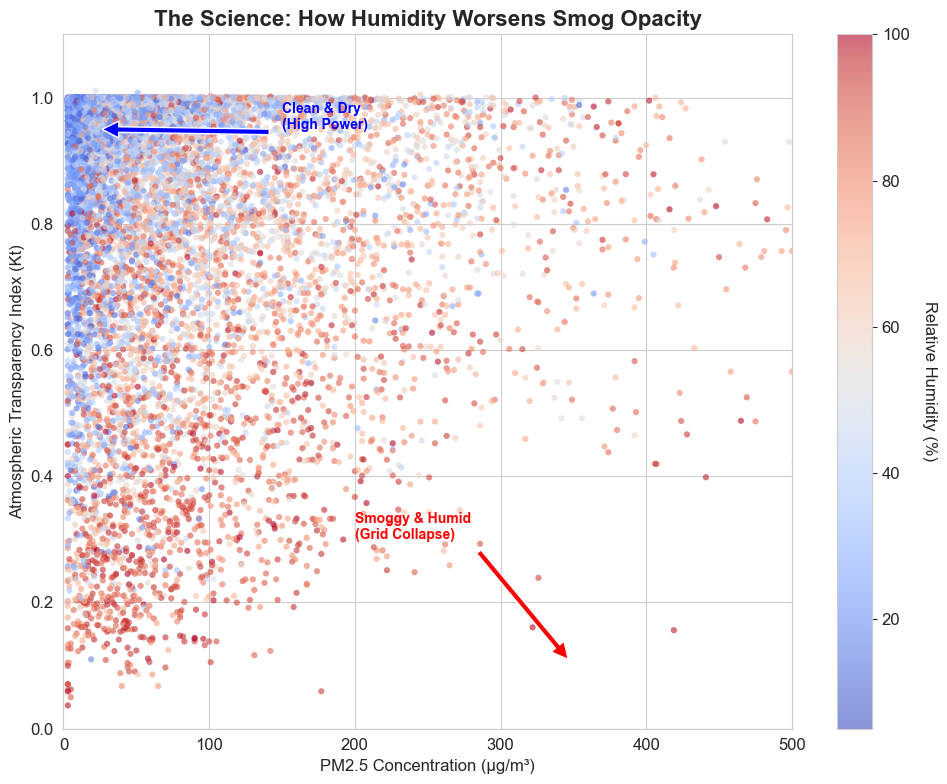

C:\Users\asus zb\AppData\Local\Temp\ipykernel_1984\491888269.py:133: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=seasonal_loss.index, y=seasonal_loss.values, palette='Reds')


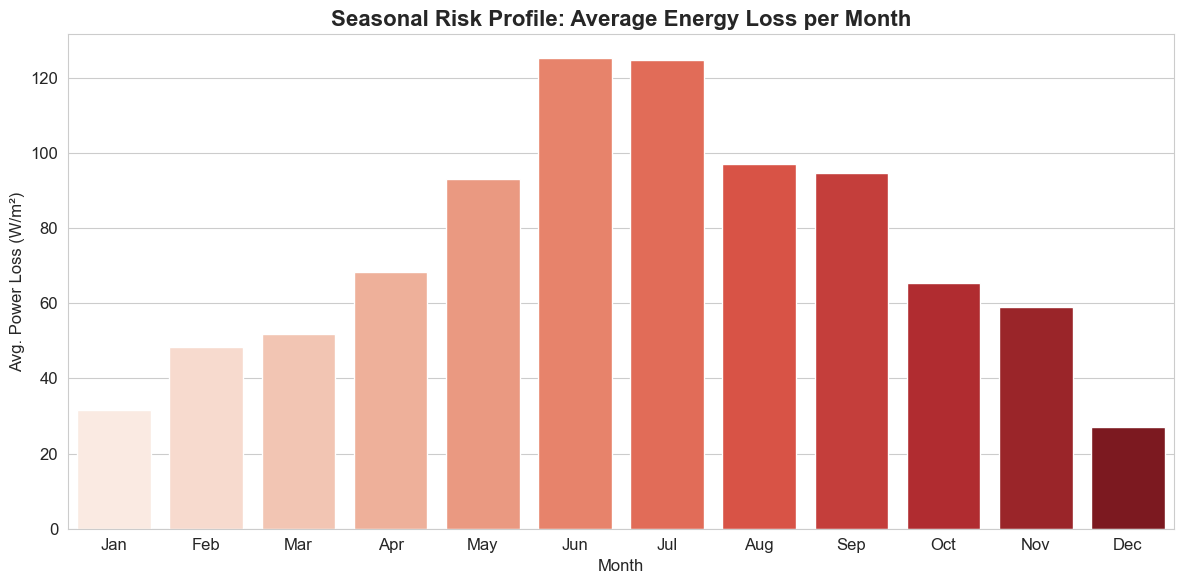

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# --- 0. PRE-VISUALIZATION SETUP ---
# Recover dates for the test set (needed for time-series plots)
# We use the index of y_test to find the corresponding dates in the original df
test_dates = df.loc[y_test.index, 'Datetime']

# Prepare Data for Physics Plot (Humidity vs Transparency)
# Filter for daytime only to avoid division by zero errors
df_day = df[df['Clear_Sky_GHI'] > 50].copy()
df_day['Kt'] = df_day['GHI'] / df_day['Clear_Sky_GHI']
df_day['Kt'] = df_day['Kt'].clip(0, 1.2) # Clip outliers

# Set visual style for academic publication quality
sns.set_style("whitegrid")
plt.rcParams.update({'font.family': 'sans-serif', 'font.size': 12})


# ========================================================
# FIGURE 1: THE BUSINESS PROBLEM (THE "COST OF SMOG")
# ========================================================
# Purpose: Shows exactly how much energy (money) is lost to pollution.
# Interpretation: The Red Area is the financial loss for the grid operator.

# We take a clear 1-week slice (168 hours) from the test set to zoom in
slice_start = 0 
slice_end = 168 

plt.figure(figsize=(15, 6))

# 1. Potential Generation (Green Dashed) - If air was clean
plt.plot(test_dates.iloc[slice_start:slice_end], 
         X_test['Clear_Sky_GHI'].iloc[slice_start:slice_end], 
         label='Potential (Clear Sky)', color='green', linestyle='--', alpha=0.8)

# 2. Actual Generation (Orange Solid) - Reality
plt.plot(test_dates.iloc[slice_start:slice_end], 
         y_test.iloc[slice_start:slice_end], 
         label='Actual (Smog Impact)', color='#e67e22', linewidth=2)

# 3. The Gap (Red Fill)
plt.fill_between(test_dates.iloc[slice_start:slice_end], 
                 y_test.iloc[slice_start:slice_end], 
                 X_test['Clear_Sky_GHI'].iloc[slice_start:slice_end], 
                 color='red', alpha=0.15, label='Lost Energy (Smog Penalty)')

plt.title("The Business Problem: Solar Energy Lost to Pollution (1 Week Sample)", fontsize=16, fontweight='bold')
plt.ylabel("Solar Irradiance (W/m²)")
plt.xlabel("Date")
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()


# ========================================================
# FIGURE 2: THE SOLUTION (FORECASTING RELIABILITY)
# ========================================================
# Purpose: Proves your model can predict these drops in advance.
# Interpretation: The Blue line tracks the Black line, meaning the grid operator is safe.

plt.figure(figsize=(15, 6))

# 1. Actual Grid Load (Black)
plt.plot(test_dates.iloc[slice_start:slice_end], 
         y_test.iloc[slice_start:slice_end], 
         label='Actual Grid Load', color='black', linewidth=2, alpha=0.7)

# 2. AI Forecast (Blue Dashed)
plt.plot(test_dates.iloc[slice_start:slice_end], 
         preds[slice_start:slice_end], 
         label='AI Forecast (Our Model)', color='#2980b9', linestyle='--', linewidth=2)

plt.title("The Solution: Forecasting Reliability (Actual vs Predicted)", fontsize=16, fontweight='bold')
plt.ylabel("Solar Irradiance (W/m²)")
plt.xlabel("Date")
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()


# ========================================================
# FIGURE 3: THE PHYSICS DRIVER (HUMIDITY MULTIPLIER)
# ========================================================
# Purpose: The "Scientific Proof" that Humidity makes Smog worse.
# Interpretation: Red dots (Humid) are always lower than Blue dots (Dry) for the same PM2.5.

plt.figure(figsize=(10, 8))

# Sample 10,000 points so the plot renders quickly
subset = df_day.sample(n=10000, random_state=42)

# Scatter Plot: X=PM2.5, Y=Transparency (Kt), Color=Humidity
sc = plt.scatter(subset['PM2.5'], subset['Kt'], 
                 c=subset['Humidity'], cmap='coolwarm', 
                 alpha=0.6, s=20, edgecolor='none')

cbar = plt.colorbar(sc)
cbar.set_label('Relative Humidity (%)', rotation=270, labelpad=20)

plt.title("The Science: How Humidity Worsens Smog Opacity", fontsize=16, fontweight='bold')
plt.xlabel("PM2.5 Concentration (µg/m³)")
plt.ylabel("Atmospheric Transparency Index (Kt)")
plt.ylim(0, 1.1)
plt.xlim(0, 500)

# Add text arrows to explain the graph to the examiner
plt.annotate("Clean & Dry\n(High Power)", xy=(20, 0.95), xytext=(150, 0.95),
             arrowprops=dict(facecolor='blue', shrink=0.05), color='blue', fontsize=10, fontweight='bold')

plt.annotate("Smoggy & Humid\n(Grid Collapse)", xy=(350, 0.1), xytext=(200, 0.3),
             arrowprops=dict(facecolor='red', shrink=0.05), color='red', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


# ========================================================
# FIGURE 4: SEASONAL RISK PROFILE
# ========================================================
# Purpose: Strategic planning for the grid operator.
# Interpretation: Shows which months have the highest financial risk.

# Calculate Loss for the whole dataset
df['Loss'] = df['Clear_Sky_GHI'] - df['GHI']

# Group by Month (only considering daylight hours)
seasonal_loss = df[df['Clear_Sky_GHI'] > 10].groupby('Month')['Loss'].mean()

plt.figure(figsize=(12, 6))
sns.barplot(x=seasonal_loss.index, y=seasonal_loss.values, palette='Reds')

plt.title("Seasonal Risk Profile: Average Energy Loss per Month", fontsize=16, fontweight='bold')
plt.xlabel("Month")
plt.ylabel("Avg. Power Loss (W/m²)")
plt.xticks(ticks=range(12), labels=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])

plt.tight_layout()
plt.show()